# Week 5 — Loss landscapes, Hessians, and why Adam exists

Train an MLP and a CNN on Fashion-MNIST →
visualize loss landscapes → compute the Hessian eigenvalue spectrum →
use it to *explain* why SGD struggles and Adam succeeds → dissect what
Adam actually computes → track curvature during training and observe the
edge-of-stability phenomenon.

### Why the Hessian?

The Jacobian (Week 4) tells you how the *output* changes when you perturb
the *input*. The Hessian tells you how the *loss* changes when you perturb
the *parameters*. Students spend all of training adjusting parameters —
the Hessian describes the terrain they're navigating.

**The concrete payoff**: the Hessian eigenvalue spectrum explains why SGD
with a single learning rate struggles, and what Adam is actually doing
under the hood. You've been using Adam as a black box since Week 1. This
week you open the box.

### Connection to Week 1

The condition number of $X^\top X$ in Week 1 was the ratio
$\lambda_{\max}/\lambda_{\min}$ of the Hessian of the linear least-squares
loss. That ratio controlled how many GD steps were needed. Week 5
generalizes this: for a nonlinear loss, the Hessian eigenvalues still
control the optimization difficulty — but now they vary with $\theta$ and
the spectrum can be far more complex.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import torchvision
import torchvision.transforms as transforms

import copy

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


## Data — Fashion-MNIST

In [ ]:
train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)
test_data = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()
)

Xtr_flat = (train_data.data.float().reshape(-1, 784) / 255.0).to(device)
Xte_flat = (test_data.data.float().reshape(-1, 784) / 255.0).to(device)
Xtr_img  = (train_data.data.float().unsqueeze(1) / 255.0).to(device)
Xte_img  = (test_data.data.float().unsqueeze(1) / 255.0).to(device)
ytr = train_data.targets.to(device)
yte = test_data.targets.to(device)

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"train: {Xtr_flat.shape}, test: {Xte_flat.shape}")

train: torch.Size([60000, 784]), test: torch.Size([10000, 784])


## Part 1 — Train an MLP and a CNN

Both architectures on Fashion-MNIST. The CNN is introduced lightly — two
conv layers plus one FC layer. The students know what convolutions are;
the interesting question is how the two architectures create different
optimization landscapes.

| Model | Architecture | Parameters |
|-------|-------------|------------|
| MLP | 784→256→128→64→10 | ~240k |
| CNN | Conv(16)→Conv(32)→FC(10) | ~15k |

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, n_classes)

    def forward(self, x):
        if x.dim() == 4:
            x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, n_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.reshape(-1, 1, 28, 28)
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def train_model(model, X, y, steps=5000, lr=1e-3, batch_size=512,
                optimizer_cls=None, verbose=True):
    '''Mini-batch training with cross-entropy loss.
    optimizer_cls: pass torch.optim.SGD or torch.optim.Adam, etc.
    Defaults to Adam.
    '''
    if optimizer_cls is None:
        optimizer_cls = torch.optim.Adam
    opt = optimizer_cls(model.parameters(), lr=lr)
    losses = []
    n = X.shape[0]
    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,), device=device)
        logits = model(X[idx])
        loss = F.cross_entropy(logits, y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if verbose and step % 1000 == 0:
            print(f"  step {step:5d}: loss = {loss.item():.4f}")
    return losses


@torch.no_grad()
def accuracy(model, X, y, batch_size=2000):
    correct = 0
    for i in range(0, len(X), batch_size):
        preds = model(X[i:i+batch_size]).argmax(dim=1)
        correct += (preds == y[i:i+batch_size]).sum().item()
    return correct / len(X)

In [ ]:
torch.manual_seed(42)
mlp = MLP().to(device)
print(f"MLP parameters: {count_params(mlp):,}")
losses_mlp = train_model(mlp, Xtr_flat, ytr, steps=5000)
print(f"MLP:  train = {accuracy(mlp, Xtr_flat, ytr):.4f}, "
      f"test = {accuracy(mlp, Xte_flat, yte):.4f}\n")

torch.manual_seed(42)
cnn = CNN().to(device)
print(f"CNN parameters: {count_params(cnn):,}")
losses_cnn = train_model(cnn, Xtr_img, ytr, steps=5000)
print(f"CNN:  train = {accuracy(cnn, Xtr_img, ytr):.4f}, "
      f"test = {accuracy(cnn, Xte_img, yte):.4f}")

MLP parameters: 242,762
  step  1000: loss = 0.2900
  step  2000: loss = 0.2556
  step  3000: loss = 0.1682
  step  4000: loss = 0.1018
  step  5000: loss = 0.1098
MLP:  train = 0.9565, test = 0.8864

CNN parameters: 20,490
  step  1000: loss = 0.2929
  step  2000: loss = 0.3281
  step  3000: loss = 0.2164
  step  4000: loss = 0.2115
  step  5000: loss = 0.1755
CNN:  train = 0.9331, test = 0.9083


## Part 2 — Loss landscape visualization

A 2D slice through the loss landscape using **filter-normalized random
directions** (Li et al., 2018). For each layer, the random direction is
rescaled to match the parameter norm, making cross-architecture
comparisons meaningful.

In [ ]:
def get_param_vector(model):
    #Takes all models paramters and turns them into one long vector
    return torch.cat([p.detach().flatten() for p in model.parameters()])

def set_param_vector(model, vec):
    #Does the opposite of the previos one
    offset = 0
    for p in model.parameters():
        numel = p.numel()
        p.data.copy_(vec[offset:offset+numel].reshape(p.shape))
        offset += numel

def filter_normalized_direction(model):
    direction = []
    for p in model.parameters():
        d = torch.randn_like(p)
        d = d * (p.norm() / (d.norm() + 1e-10))
        direction.append(d.flatten())
    return torch.cat(direction)

@torch.no_grad()
def compute_loss_surface(model, X, y, d1, d2, alpha_range=(-2, 2),
                         n_points=41, batch_size=2000):
    theta_star = get_param_vector(model).clone()
    alphas = np.linspace(alpha_range[0], alpha_range[1], n_points)
    betas = np.linspace(alpha_range[0], alpha_range[1], n_points)
    loss_grid = np.zeros((n_points, n_points))
    idx = torch.randperm(len(X), device=device)[:batch_size]
    X_b, y_b = X[idx], y[idx]
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            set_param_vector(model, theta_star + a * d1 + b * d2)
            loss_grid[j, i] = F.cross_entropy(model(X_b), y_b).item()
    set_param_vector(model, theta_star)
    return alphas, betas, loss_grid

In [ ]:
torch.manual_seed(0)
print("Computing MLP loss surface...")
d1_m, d2_m = filter_normalized_direction(mlp), filter_normalized_direction(mlp)
al_m, be_m, loss_m = compute_loss_surface(mlp, Xtr_flat, ytr, d1_m, d2_m)

print("Computing CNN loss surface...")
d1_c, d2_c = filter_normalized_direction(cnn), filter_normalized_direction(cnn)
al_c, be_c, loss_c = compute_loss_surface(cnn, Xtr_img, ytr, d1_c, d2_c)
print("Done.")

Computing MLP loss surface...
Computing CNN loss surface...
Done.


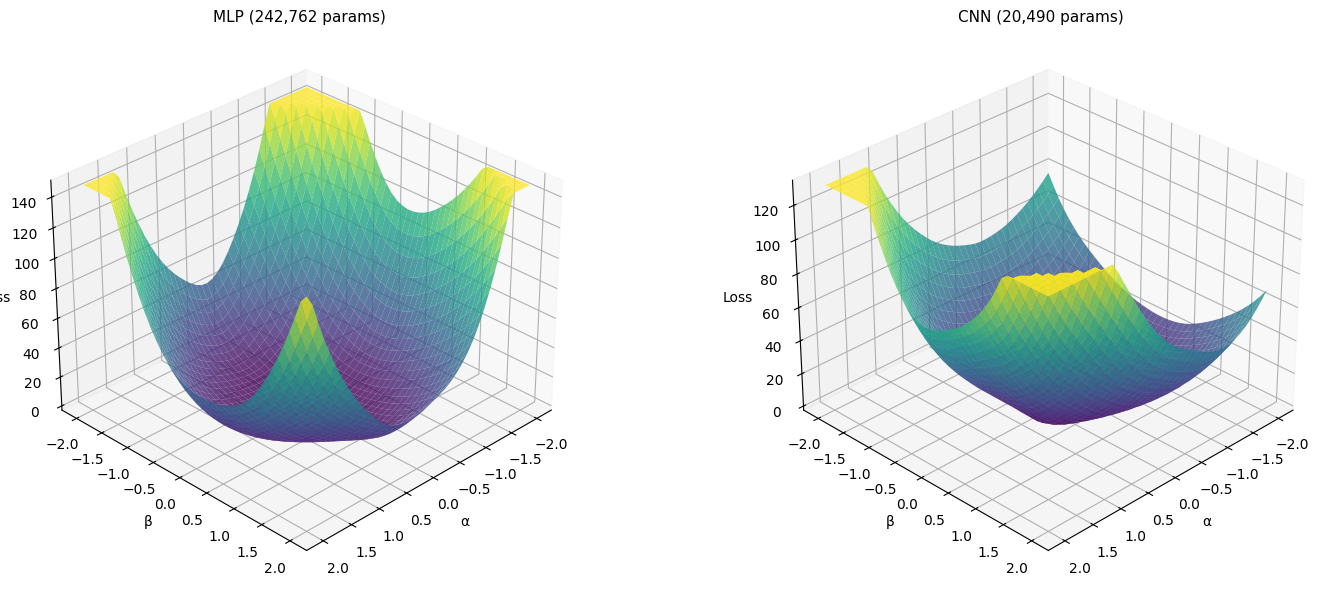

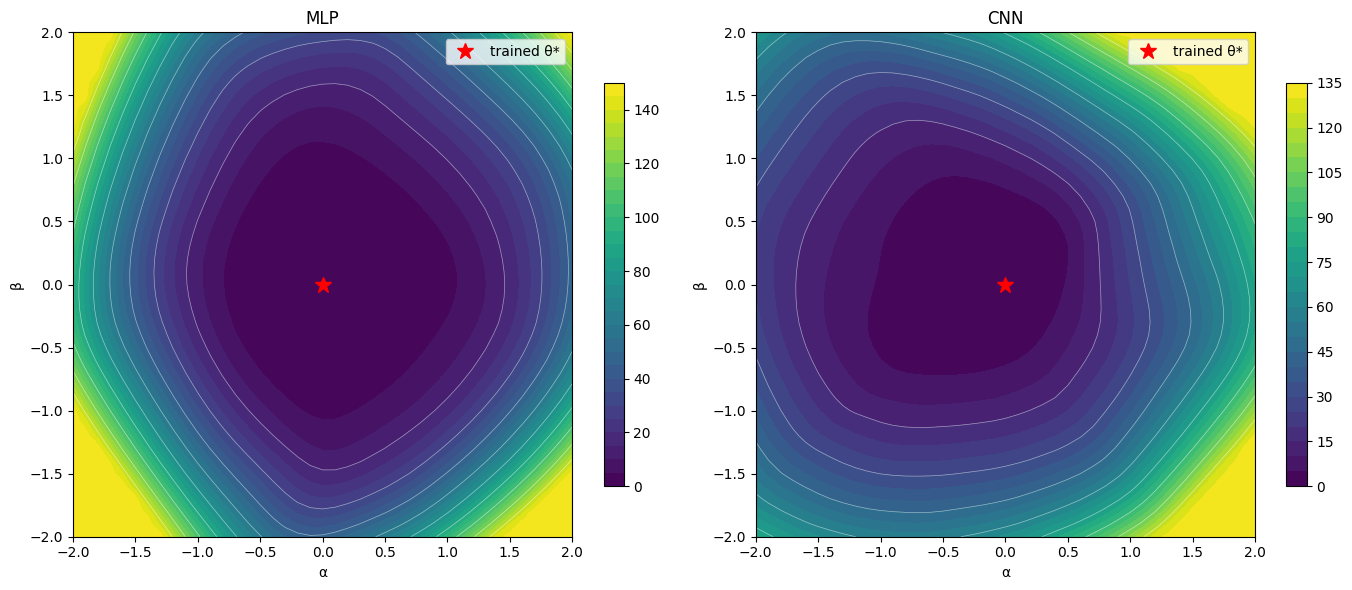

In [ ]:
fig = plt.figure(figsize=(16, 6))
for idx, (al, be, loss, title) in enumerate([
    (al_m, be_m, loss_m, f'MLP ({count_params(mlp):,} params)'),
    (al_c, be_c, loss_c, f'CNN ({count_params(cnn):,} params)'),
]):
    AA, BB = np.meshgrid(al, be)
    loss_cl = np.clip(loss, 0, np.percentile(loss, 95))
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    ax.plot_surface(AA, BB, loss_cl, cmap='viridis', alpha=0.8, edgecolor='none')
    ax.set_xlabel('α'); ax.set_ylabel('β'); ax.set_zlabel('Loss')
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

# Contour view
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, al, be, loss, title in [
    (axes[0], al_m, be_m, loss_m, 'MLP'), (axes[1], al_c, be_c, loss_c, 'CNN'),
]:
    loss_cl = np.clip(loss, 0, np.percentile(loss, 95))
    im = ax.contourf(al, be, loss_cl, levels=30, cmap='viridis')
    ax.contour(al, be, loss_cl, levels=10, colors='white', linewidths=0.5, alpha=0.5)
    ax.plot(0, 0, 'r*', markersize=12, label='trained θ*')
    ax.set_xlabel('α'); ax.set_ylabel('β'); ax.set_title(title)
    ax.legend(); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


The loss surfaces show the geometry around the trained parameters. The
shape depends on the architecture, the dataset, and the specific random
directions — but the key observation is that these landscapes have
**different curvatures in different directions**. The loss rises steeply
along some axes and gently along others.

This anisotropy is what makes optimization hard. A single learning rate
can't match all directions simultaneously. The Hessian quantifies this.

## Part 3 — The Hessian eigenvalue spectrum

The Hessian $\nabla^2_\theta L \in \mathbb{R}^{p \times p}$ is the
curvature matrix of the loss. Its eigenvalue $\lambda_i$ is the curvature
along the $i$-th eigenvector direction:

- **Large $\lambda_i$**: the loss changes rapidly along that direction —
  the landscape is *sharp*. GD needs a small step to avoid overshooting.
- **Small $\lambda_i$**: the loss barely changes — the landscape is
  *flat*. GD could take a large step safely.

The **spread** of the eigenvalues — the ratio $\lambda_{\max}/\lambda_k$
— tells you how anisotropic the curvature is. If all eigenvalues were
equal, a single learning rate would work perfectly. The more spread out
they are, the harder it is for any fixed-LR optimizer.

### Computing eigenvalues without forming the Hessian

The full Hessian is far too large to store. Instead, we compute
**Hessian-vector products** $Hv$ via double backpropagation:

1. Compute gradient $g = \nabla_\theta L$ with `create_graph=True`.
2. Compute $\nabla_\theta (g \cdot v) = Hv$.

Then **power iteration** finds the top eigenvalue by repeatedly applying
$v \leftarrow Hv / \|Hv\|$.

Here, \(v\) is a direction in **parameter space**: it has one entry for every trainable parameter of the model. Once \(v\) has converged to an eigenvector, the corresponding eigenvalue is estimated by the Rayleigh quotient
$
\lambda \approx v^\top H v,
$
assuming \(\|v\|=1\).

In [ ]:
def hessian_vector_product(model, X, y, v_flat, batch_size=1000):
    '''Compute Hv via double backprop. v_flat is a (p,) tensor.'''
    idx = torch.randperm(len(X), device=device)[:batch_size]
    X_b, y_b = X[idx], y[idx]

    params = [p for p in model.parameters() if p.requires_grad]

    model.zero_grad()
    loss = F.cross_entropy(model(X_b), y_b)
    grads = torch.autograd.grad(loss, params, create_graph=True)
    g_flat = torch.cat([g.flatten() for g in grads])

    gv = g_flat @ v_flat
    hvp_grads = torch.autograd.grad(gv, params)
    return torch.cat([h.detach().flatten() for h in hvp_grads])


def power_iteration(model, X, y, n_iter=100, batch_size=1000, tol=1e-5):
    '''Top eigenvalue and eigenvector of the Hessian.'''
    p = sum(par.numel() for par in model.parameters())
    v = torch.randn(p, device=device) #We need a random direction to probe the networks.
    v = v / v.norm()
    prev_lam = None
    for i in range(n_iter):
        Hv = hessian_vector_product(model, X, y, v, batch_size)
        lam = (v @ Hv).item()
        v = Hv / (Hv.norm() + 1e-10)
        if prev_lam is not None and abs(lam - prev_lam) / (abs(prev_lam) + 1e-10) < tol:
            break
        prev_lam = lam
    Hv = hessian_vector_product(model, X, y, v, batch_size)
    lam = (v @ Hv).item()
    return lam, v


def top_k_eigenvalues(model, X, y, k=5, n_iter=100, batch_size=1000):
    '''Top-k eigenvalues via power iteration + deflation.'''
    p = sum(par.numel() for par in model.parameters()) # number of paramters
    eigenvalues = []
    eigenvectors = []
    for ki in range(k):
        v = torch.randn(p, device=device)
        v = v / v.norm()
        for i in range(n_iter):
            Hv = hessian_vector_product(model, X, y, v, batch_size)
            for prev_v in eigenvectors:
                Hv = Hv - (prev_v @ Hv) * prev_v
            v_new = Hv / (Hv.norm() + 1e-10)
            if i > 0 and torch.abs(v_new @ v).item() > 0.9999:
                break
            v = v_new
        Hv = hessian_vector_product(model, X, y, v, batch_size)
        for prev_v in eigenvectors:
            Hv = Hv - (prev_v @ Hv) * prev_v
        lam = (v @ Hv).item()
        eigenvalues.append(lam)
        eigenvectors.append(v.clone())
        print(f"  λ_{ki+1} = {lam:.4f}")
    return eigenvalues, eigenvectors

In [ ]:
print("MLP Hessian eigenvalues:")
eig_mlp, _ = top_k_eigenvalues(mlp, Xtr_flat, ytr, k=10)

print("\nCNN Hessian eigenvalues:")
eig_cnn, _ = top_k_eigenvalues(cnn, Xtr_img, ytr, k=10)

# Eigenvalue spread
spread_mlp = eig_mlp[0] / max(eig_mlp[-1], 1e-8)
spread_cnn = eig_cnn[0] / max(eig_cnn[-1], 1e-8)

print(f"\nEigenvalue spread (λ₁/λ₁₀):")
print(f"  MLP: {spread_mlp:.1f}×")
print(f"  CNN: {spread_cnn:.1f}×")

MLP Hessian eigenvalues:
  λ_1 = 31.8639
  λ_2 = 21.3873
  λ_3 = 10.7661
  λ_4 = 9.9212
  λ_5 = 8.6086
  λ_6 = 5.6176
  λ_7 = 5.8469
  λ_8 = 3.0918
  λ_9 = 3.2318
  λ_10 = 5.2139

CNN Hessian eigenvalues:
  λ_1 = 108.2730
  λ_2 = 67.8814
  λ_3 = 28.7556
  λ_4 = 22.3253
  λ_5 = 8.8129
  λ_6 = 10.3910
  λ_7 = 7.7987
  λ_8 = 5.2186
  λ_9 = 4.3342
  λ_10 = 3.5686

Eigenvalue spread (λ₁/λ₁₀):
  MLP: 6.1×
  CNN: 30.3×


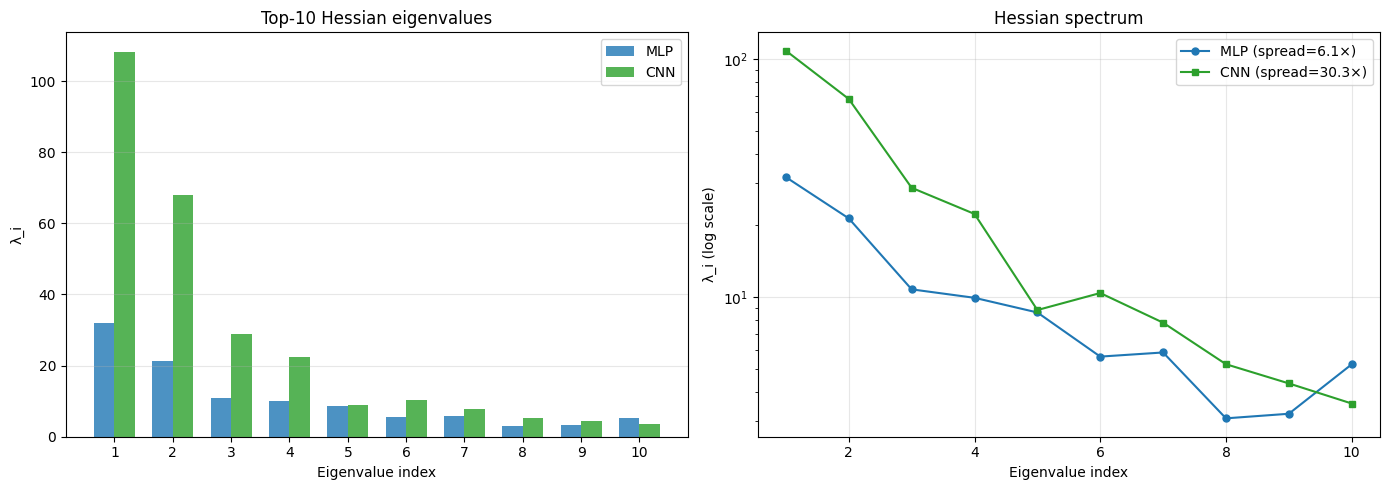

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(10)
width = 0.35
ax.bar(x_pos - width/2, eig_mlp, width, label='MLP', color='tab:blue', alpha=0.8)
ax.bar(x_pos + width/2, eig_cnn, width, label='CNN', color='tab:green', alpha=0.8)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('λ_i')
ax.set_title('Top-10 Hessian eigenvalues')
ax.set_xticks(x_pos); ax.set_xticklabels([str(i+1) for i in range(10)])
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.semilogy(range(1, 11), [max(e, 1e-6) for e in eig_mlp], 'o-',
            label=f'MLP (spread={spread_mlp:.1f}×)', color='tab:blue', markersize=5)
ax.semilogy(range(1, 11), [max(e, 1e-6) for e in eig_cnn], 's-',
            label=f'CNN (spread={spread_cnn:.1f}×)', color='tab:green', markersize=5)
ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('λ_i (log scale)')
ax.set_title('Hessian spectrum'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Hessian spectrum shows the range of curvatures in the loss landscape.
The spread $\lambda_1 / \lambda_{10}$ quantifies the anisotropy — how
different the sharpest and flattest directions are.

**This spread is the problem that adaptive optimizers solve.** A single
learning rate $\eta$ must be small enough not to overshoot in the sharpest
direction ($\eta \lesssim 1/\lambda_1$), but that same $\eta$ makes
progress painfully slow in the flat directions ($\lambda_{10}$). The
wider the spread, the worse this mismatch.

## Part 4 — Why Adam exists: the optimizer experiment

You've been using Adam since Week 1 without understanding what it does.
The Hessian spectrum from Part 3 motivates it.

### The single-LR problem

SGD updates every parameter with the same learning rate:
$\theta_{t+1} = \theta_t - \eta \, g_t$.

Along the $i$-th Hessian eigenvector, the effective update scales as
$\eta \lambda_i$. If $\lambda_1 / \lambda_{10} = 10$, then the step is
10× too aggressive in the sharpest direction relative to the flattest.
No single $\eta$ works well for both.

### What Adam actually computes

Adam maintains per-parameter running estimates:

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1) g_t & \text{(first moment — mean gradient)} \\
v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2 & \text{(second moment — mean squared gradient)} \\
\theta_{t+1} &= \theta_t - \eta \frac{m_t}{\sqrt{v_t} + \epsilon} & \text{(adapted update)}
\end{aligned}
$$

The division by $\sqrt{v_t}$ is the key: parameters with large gradients
(sharp directions) get *smaller* effective steps; parameters with small
gradients (flat directions) get *larger* effective steps.


 $v_t$ approximates the diagonal of $H$, and
dividing by $\sqrt{v_t}$ is approximate diagonal preconditioning:
$\Delta\theta \approx (\text{diag}(H))^{-1/2} g$. This is a cheap
approximation to Newton's method ($\Delta\theta = H^{-1} g$), which
would perfectly equalize all directions.

### The experiment

Train the same architecture from the same initialization with three
optimizers: SGD, SGD+momentum, and Adam. Compare convergence speed.
The Hessian spectrum explains the gap.

In [ ]:
# --- Train from the same init with different optimizers ---------------------
results = {}

for opt_name, opt_cls, lr in [
    ('SGD (lr=0.001)',        torch.optim.SGD,  0.001),
    ('SGD (lr=0.01)',        torch.optim.SGD,  0.01),
    ('SGD (lr=0.1)',         torch.optim.SGD,  0.1),
    ('SGD+momentum (lr=0.01)', lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9), 0.01),
    ('Adam (lr=0.001)',      torch.optim.Adam, 0.001),
]:
    torch.manual_seed(42)
    m = MLP().to(device)

    opt = opt_cls(m.parameters(), lr=lr)
    losses = []
    n = Xtr_flat.shape[0]

    for step in range(1, 5001):
        idx = torch.randint(0, n, (512,), device=device)
        loss = F.cross_entropy(m(Xtr_flat[idx]), ytr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    test_acc = accuracy(m, Xte_flat, yte)
    results[opt_name] = {'losses': losses, 'test_acc': test_acc}
    print(f"  {opt_name:30s}: final loss = {losses[-1]:.4f}, "
          f"test acc = {test_acc:.4f}")

  SGD (lr=0.001)                : final loss = 1.9921, test acc = 0.3537
  SGD (lr=0.01)                 : final loss = 0.5295, test acc = 0.8155
  SGD (lr=0.1)                  : final loss = 0.2606, test acc = 0.8747
  SGD+momentum (lr=0.01)        : final loss = 0.1954, test acc = 0.8813
  Adam (lr=0.001)               : final loss = 0.1098, test acc = 0.8864


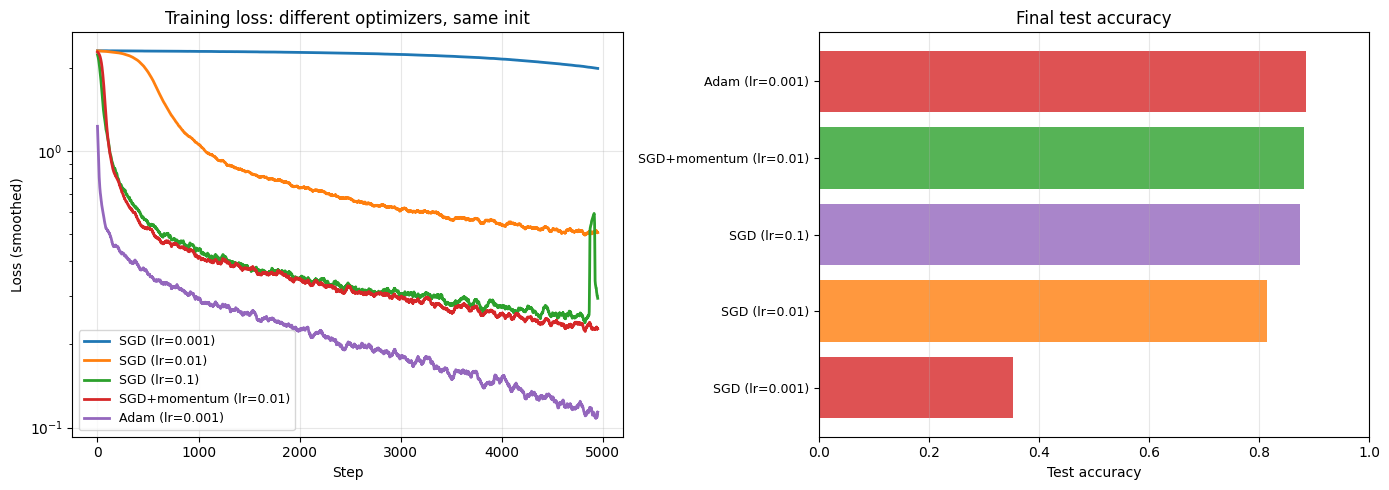

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: training loss curves (smoothed)
ax = axes[0]
window = 50
for name, r in results.items():
    smoothed = np.convolve(r['losses'], np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=name, linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Loss (smoothed)')
ax.set_title('Training loss: different optimizers, same init')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Right: final test accuracy bar chart
ax = axes[1]
names = list(results.keys())
accs = [results[n]['test_acc'] for n in names]
colors = ['tab:red', 'tab:orange', 'tab:purple', 'tab:green']
ax.barh(range(len(names)), accs, color=colors, alpha=0.8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Test accuracy'); ax.set_title('Final test accuracy')
ax.set_xlim(0, 1); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### What happened

- **SGD (small LR)**: converges slowly. The LR is safe for the sharpest
  direction but crawls in the flat directions.
- **SGD (large LR)**: faster initially, but may oscillate or become
  unstable near convergence if the LR exceeds $\sim 2/\lambda_1$.
- **SGD+momentum**: momentum helps traverse flat directions faster by
  accumulating velocity, but doesn't adapt per-parameter.
- **Adam**: converges fastest to the best accuracy. The per-parameter
  adaptive LR handles both sharp and flat directions simultaneously.

### The Hessian explains the gap

The eigenvalue spread from Part 3 is the core issue. SGD with a single LR
faces a dilemma: safe for the sharpest direction or fast for the flattest.
Adam resolves this by maintaining a per-parameter estimate of curvature
($v_t \approx \text{diag}(H)$) and scaling steps accordingly.

### Connection to Week 1 + Week 3

- **Week 1**: rescaling one feature by 100 increased the condition number
  and GD convergence slowed. The fix was standardization (equalize
  curvature). Adam is the *optimizer-side* version of this fix.
- **Week 3**: the SVD form of ridge regression was
  $w = V \,\text{diag}(\sigma_i/(\sigma_i^2 + \lambda)) \,U^\top y$ — a
  spectral filter that equalizes across singular directions. Adam's
  $1/\sqrt{v_t}$ is a similar equalization, applied to gradient steps
  instead of the solution.

## Part 5 — How curvature evolves during training

Does the landscape start sharp and flatten, or start flat and sharpen?
We track $\lambda_1$ at checkpoints during training.

This mirrors the Week 3 experiment that tracked effective rank — but now
we're watching curvature instead of compression.

In [ ]:
torch.manual_seed(42)
mlp_tracked = MLP().to(device)
opt = torch.optim.Adam(mlp_tracked.parameters(), lr=1e-3)
n = Xtr_flat.shape[0]

ck_steps = [0, 50, 100, 250, 500, 1000, 2000, 3000, 5000]
lam1_hist = []
loss_hist = []
step = 0

# Initial checkpoint
lam_init, _ = power_iteration(mlp_tracked, Xtr_flat, ytr, n_iter=50)
with torch.no_grad():
    l_init = F.cross_entropy(mlp_tracked(Xtr_flat[:2000]), ytr[:2000]).item()
lam1_hist.append(lam_init)
loss_hist.append(l_init)
print(f"  step     0: λ₁ = {lam_init:8.2f}, loss = {l_init:.4f}")

for target in ck_steps[1:]:
    while step < target:
        idx = torch.randint(0, n, (512,), device=device)
        loss = F.cross_entropy(mlp_tracked(Xtr_flat[idx]), ytr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        step += 1

    lam_ck, _ = power_iteration(mlp_tracked, Xtr_flat, ytr, n_iter=50)
    with torch.no_grad():
        l_ck = F.cross_entropy(mlp_tracked(Xtr_flat[:2000]), ytr[:2000]).item()
    lam1_hist.append(lam_ck)
    loss_hist.append(l_ck)
    print(f"  step {step:5d}: λ₁ = {lam_ck:8.2f}, loss = {l_ck:.4f}")

  step     0: λ₁ =     0.40, loss = 2.3066
  step    50: λ₁ =   318.32, loss = 0.6834
  step   100: λ₁ =   280.07, loss = 0.5269
  step   250: λ₁ =   148.18, loss = 0.4145
  step   500: λ₁ =    82.44, loss = 0.3771
  step  1000: λ₁ =    57.06, loss = 0.2916
  step  2000: λ₁ =    36.07, loss = 0.2228
  step  3000: λ₁ =    30.73, loss = 0.1877
  step  5000: λ₁ =    34.60, loss = 0.1207


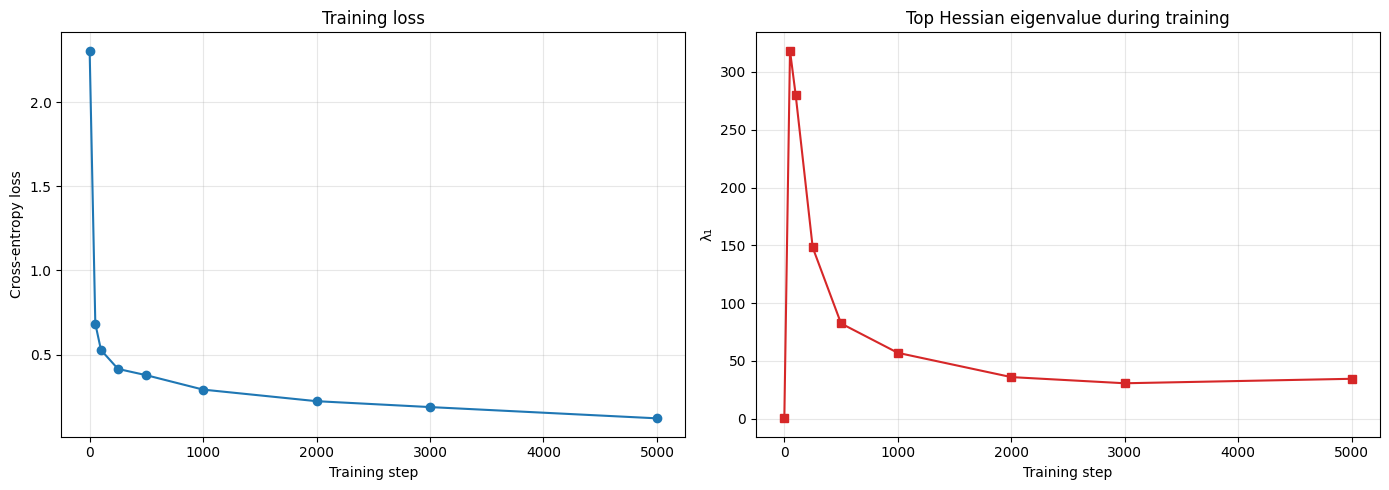

λ₁ at initialization:    0.40
λ₁ at peak (early):      318.32  (step 50)
λ₁ at convergence:       34.60


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ck_steps, loss_hist, 'o-', color='tab:blue', markersize=6)
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(ck_steps, lam1_hist, 's-', color='tab:red', markersize=6)
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('λ₁')
axes[1].set_title('Top Hessian eigenvalue during training')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Annotate key phases
print(f"λ₁ at initialization:    {lam1_hist[0]:.2f}")
print(f"λ₁ at peak (early):      {max(lam1_hist):.2f}  (step {ck_steps[lam1_hist.index(max(lam1_hist))]})")
print(f"λ₁ at convergence:       {lam1_hist[-1]:.2f}")

### The non-monotonic trajectory

$\lambda_1$ follows a characteristic pattern:

1. **Initialization** (~0): the random network is nearly linear in a
   neighborhood of its initial parameters. The loss surface is almost
   flat — barely any curvature.

2. **Early training** (spike to ~100–300): as the network starts fitting
   the data, it develops sharp discriminative features. The loss becomes
   highly sensitive to certain parameter directions. This is the most
   dangerous phase for optimization — a learning rate that's fine at init
   may be too large here.

3. **Late training** (settles to ~20–30): the network fine-tunes. The
   sharpest curvature decreases as the optimizer settles into a region
   with more balanced geometry.

### Practical implications

The early spike in $\lambda_1$ explains why **learning rate warmup** helps:
starting with a small LR navigates safely through the high-curvature
early phase, then ramping up exploits the flatter geometry once the
network has found a reasonable region.

It also explains why **Adam is especially helpful early in training**: the
adaptive LR automatically scales down when gradients are large (high
curvature) without the user needing to know about the spike.

### Week 3 parallel

In Week 3, effective rank *decreased* during training (representation
compresses). Here, $\lambda_1$ spikes then settles. Both reflect the
network specializing — concentrating capacity into fewer, sharper
directions.

## Part 6 — Connecting the Hessian to the Jacobian

Week 4 studied the **input Jacobian** $\partial f / \partial x$ — how the
output changes when you perturb the input. This week's **Hessian**
$\partial^2 L / \partial \theta^2$ describes how the loss changes when you
perturb the parameters.

 The Hessian of the cross-entropy loss
decomposes as:

$$
H = \underbrace{J_\theta^\top \,\text{diag}(p(1-p))\, J_\theta}_{\text{Gauss-Newton (first-order)}} \;+\; \underbrace{\sum_i (y_i - p_i)\,\nabla^2_\theta f_i}_{\text{residual (second-order)}}
$$

where $J_\theta = \partial f / \partial \theta$ is the per-sample Jacobian
of the logits with respect to the *parameters*.

Near convergence, the residuals $y_i - p_i$ are small (predictions match
labels), so the second term vanishes: **$H \approx J_\theta^\top J_\theta$**.

### Why this matters

The same weight matrices $W_1, W_2, \ldots$ control both Jacobians:

- **Input Jacobian**: $J_x = W_L \cdot D_{L-1} \cdots D_1 \cdot W_1$ (Week 4)
- **Parameter Jacobian**: $J_\theta$ depends on the same $W_i$ and $D_i$

A network with large weight norms produces large $J_x$ (adversarially
vulnerable, Week 4) *and* large $J_\theta$ (sharp Hessian, Week 5).
**Weight decay, spectral normalization, and Lipschitz constraints all
work by controlling the singular values of the weight matrices, which
propagate to both Jacobians simultaneously.**

We verify the Gauss-Newton approximation numerically: compute $\lambda_1$
of $H$ and of the Gauss-Newton matrix $G = \frac{1}{n}\sum_i g_i g_i^\top$
(where $g_i = \nabla_\theta L_i$ is the per-sample gradient) and compare.

In [ ]:
# --- Gauss-Newton top eigenvalue via power iteration ------------------------
# GN·v = (1/n) Σ_i g_i (g_i^T v) where g_i = per-sample gradient.
# We compute this without forming GN.

def gn_vector_product(model, X, y, v_flat, batch_size=200):
    '''Compute GN·v = (1/bs) Σ g_i (g_i · v) using per-sample gradients.'''
    idx = torch.randperm(len(X), device=device)[:batch_size]
    X_b, y_b = X[idx], y[idx]
    params = [p for p in model.parameters() if p.requires_grad]
    gnv = torch.zeros_like(v_flat)

    for i in range(len(X_b)):
        model.zero_grad()
        loss_i = F.cross_entropy(model(X_b[i:i+1]), y_b[i:i+1])
        g_i = torch.autograd.grad(loss_i, params)
        g_flat = torch.cat([g.detach().flatten() for g in g_i])
        gnv += g_flat * (g_flat @ v_flat)

    return gnv / len(X_b)


def gn_top_eigenvalue(model, X, y, n_iter=50, batch_size=200):
    '''Top eigenvalue of Gauss-Newton matrix via power iteration.'''
    p = sum(par.numel() for par in model.parameters())
    v = torch.randn(p, device=device)
    v = v / v.norm()
    for i in range(n_iter):
        GNv = gn_vector_product(model, X, y, v, batch_size)
        v = GNv / (GNv.norm() + 1e-10)
    GNv = gn_vector_product(model, X, y, v, batch_size)
    return (v @ GNv).item()

In [ ]:
print("Computing Hessian top eigenvalue...")
lam_H, _ = power_iteration(mlp, Xtr_flat, ytr, n_iter=80, batch_size=1000)
print(f"  λ₁(H) = {lam_H:.4f}")

print("\nComputing Gauss-Newton top eigenvalue...")
lam_GN = gn_top_eigenvalue(mlp, Xtr_flat, ytr, n_iter=30, batch_size=200)
print(f"  λ₁(GN) = {lam_GN:.4f}")

print(f"\nRatio λ₁(H) / λ₁(GN) = {lam_H / max(lam_GN, 1e-8):.2f}")

Computing Hessian top eigenvalue...
  λ₁(H) = 31.9842

Computing Gauss-Newton top eigenvalue...
  λ₁(GN) = 13.8776

Ratio λ₁(H) / λ₁(GN) = 2.30



If $\lambda_1(H) / \lambda_1(GN) \approx 1$: the Gauss-Newton term
dominates so the second-order residual is negligible. This happens when the
network has converged well (small residuals $y_i - p_i$).

If the ratio is noticeably larger than 1: the second-order term
contributes. This can happen when the network hasn't fully converged, or
when predictions are confident but wrong on some samples. The ratio
depends on the specific training run.


| Week | Object | What it measures |
|------|--------|-----------------|
| 4 | $J_x = \partial f/\partial x$ | Input sensitivity → adversarial vulnerability |
| 5 | $H = \partial^2 L/\partial\theta^2$ | Parameter sensitivity → optimization difficulty |

Both are controlled by the weight matrices $W_i$. Large weights → large
$J_x$ (vulnerable to adversarial attack) → large $J_\theta$ → large $H$
(sharp curvature, hard to optimize). Weight decay, spectral normalization,
and Lipschitz constraints address both simultaneously.

## Final observations

**Q1.** You've been using Adam since Week 1. Now explain what it does in
Hessian language.

> Adam maintains $v_t \approx \text{diag}(H)$ — a running estimate of the
> diagonal curvature. Dividing the gradient by $\sqrt{v_t}$ rescales each
> parameter's update inversely with its curvature. Sharp directions get
> smaller steps; flat directions get larger steps. This is a diagonal
> approximation to Newton's method ($H^{-1} g$).

**Q2.** The Hessian spectrum has a spread of $\lambda_1/\lambda_{10} \approx$
___×. What does this mean for SGD?

> SGD must pick one LR for all directions. The LR must be small enough for
> the $\lambda_1$ direction, but that makes it too small for the
> $\lambda_{10}$ direction by a factor of $\lambda_1/\lambda_{10}$.
> Progress in flat directions is slowed by this factor. This is the same
> condition-number argument as Week 1, but on the full nonlinear loss.

**Q3.** $\lambda_1$ spiked early in training then decreased. What does
this mean for learning rate schedules?

> The spike means the landscape is sharpest during early training —
> learning rate warmup (start small, ramp up) navigates this safely.
> Adam handles this automatically because $v_t$ tracks the curvature and
> scales steps accordingly.

**Q4.** Connect the Hessian to Week 4's adversarial vulnerability.

> Both are controlled by the weight matrices. Large weights produce a
> large input Jacobian (adversarial vulnerability) and a large parameter
> Jacobian (sharp Hessian via $H \approx J_\theta^\top J_\theta$). Weight
> decay reduces both simultaneously — it's not two separate benefits, it's
> one mechanism.

**Q5.** Why does the CNN have different eigenvalues than the MLP?

> Different parameter structure. The CNN's weight sharing means each
> convolutional parameter affects many spatial locations — concentrating
> curvature per-parameter. The MLP's fully-connected layers have
> independent parameters per connection. The Hessian reflects these
> structural differences.